# PID Control of a Second Order System

## Preparations

Here we import all necessary libraries.

In [59]:
from IPython.core.display import HTML
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
})

from sympy import *
from sympy.plotting import plot

from mathprint import *

These are some variables that we are going to use: 

$t, s, \tau, \omega, \omega_n, \zeta$

In [60]:
from sympy.physics.control.lti import TransferFunction
Kp, Ki, Kd = symbols('K_p K_i K_d', positive=True)

t       = symbols('t', positive=True)
s       = symbols('s', complex=True)
tau     = symbols('tau', positive=True)

omega   = symbols("omega", positive=True)
omega_n = symbols('omega_n', positive=True)
zeta    = symbols('zeta', positive=True)

Let us define some helper functions.

In [61]:
def laplace(f):
    F = laplace_transform(f, t, s, noconds=True)
    return F

def ilaplace(F):
    f = inverse_laplace_transform(F, s, t)
    return f

def frac_to_tf(frac):
    return TransferFunction(fraction(frac)[0], fraction(frac)[1], s)

## System and the control equations

![](./images/p21.png)

The diagram above corresponds to a unity-feedback loop with

$$
G(s)=K_p+\frac{K_i}{s}+K_d
$$

and plant

$$
H(s)=\frac{1}{s^2 + 2 \zeta \omega_n s +\omega_n^2}.
$$

Thus, the closed-loop transfer function is

$$
\boxed{\frac{C(s)}{R(s)}
=
\frac{K_d s^2+K_p s+K_i}{s^2+\left(K_d+2 \omega_n\right) s^2+\left(K_p+\omega_n^2\right) s+K_i}}
$$

After this, we will compute $c(t)$, $c'(t)$, $c(0)$, $c'(0)$, and $c(\infty)$ where $c(t)$ is the inverse Laplace of $C(s)$. 

__From $c(\infty)$, we can get the steady state output of the controlled system while $c'(0)$ tells us the occurance of derivative kick in the controlled system (non-zero initial velocity).__



In [62]:
H = 1 / (s**2+2*zeta*omega_n*s+omega_n**2)
G = Kp + Ki/s + Kd*s        # PID TF
Q = factor(G*H / (1 + G*H)) # CL TF
Q = collect(Q, [s**3, s**2, s])

print("First-order system:")
mprint("H(s)=", latex(H))

print("PID-control:")
mprint("G(s)= ", latex(G))

print("The resulting closed-loop system:")
mprint("Q(s)=", latex(Q))

First-order system:


<IPython.core.display.Math object>

PID-control:


<IPython.core.display.Math object>

The resulting closed-loop system:


<IPython.core.display.Math object>

At this point, we can tell that the equations are already complicated, thus, finding some equations for further analysis might not be feasible. What we are going to do next is steady state analysis for several combinations of controller terms.

## Second-order system with P-control 

In [63]:
Qp = simplify(Q.subs(([Kd, 0],
                      [Ki, 0])))

mprint("Q_P=", latex(Qp))

<IPython.core.display.Math object>

For step response, we apply $1/s$ as its input, perform an inverse Laplace operation to $C(s)$ and obtain $c(t)$ as the result. Finally, we compute the steady state-value for the output: $c_{ss} = \lim_{t \to \infty} c(t)$.

In [64]:
cp = logcombine(ilaplace(Qp * 1/s))
cssp = simplify(limit(cp, t, 'oo'))
c0p  = limit(cp, t, 0)
cp_d  = simplify(diff(cp, t))
c0p_d  = limit(cp_d, t, 0)

mprint("c(t) = ", latex(cp))
mprint("c'(t) = ", latex(cp_d))
mprintb("c_{ss} = ", latex(cssp))
mprintb("c(0) = ", latex(c0p))
mprintb("c'(0) = ", latex(c0p_d))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Our conclusions: 
- no derivative kick
- smooth start
- zero initial velocity

Next, we can write the steady state error as: $e_{ss} = 1 - c_{ss}$

In [65]:
mprintb("e_{ss}=", latex(simplify(1-cssp)))

<IPython.core.display.Math object>

Next, let us try with some numerical valuses.

In [66]:
omega_n_ = 1
zeta_ = 1;
Kp_  = [1, 2, 4, 8, 20]

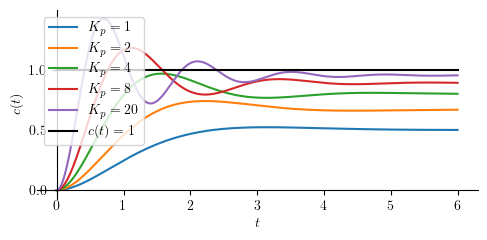

In [67]:
p = [plot(cp.subs(([zeta, zeta_], [omega_n, omega_n_], [Kp, Kp_[j]])), 
          (t, 0, 6), size=(5, 2.5), ylabel='$c(t)$', show=False, legend=True) 
     for j in range(len(Kp_))]

p1 = plot(1, (t, 0, 6), line_color='k', line_style=':', show=False) # unit-step
p1[0].label = "$c(t)=1$"
for j in range(len(p)):
    p[j][0].label = "$K_p=" + str(Kp_[j]) + "$"
    if j > 0:
        p[0].append(p[j][0])

p[0].append(p1[0])
p[0].show()

As evidenced by the gap between the response and the black target line, P-control results in a permanent steady-state offset. __The P-control cannot drive the error to zero__.

## Second-order system with PD-control 

Closed-loop transfer function:

In [68]:
Qpd = simplify(Q.subs(Ki, 0))
mprint("Q_{PD}=", latex(Qpd))


<IPython.core.display.Math object>

Next, we perform an inverse Laplace operation to $C(s)$ and obtain $c(t)$ as the result. Additionally, we will also compute the steady state-value for the output ($c_{ss}$).

A phenomenon that can be observed in a derivative control is the "kick" that happens when a step input is applied to the controlled system. Because of the kick, system output does not start from zero. 

In [94]:
cpd    = logcombine(ilaplace(Qpd * 1/s))
cpd_d  = powsimp(factor((diff(cpd, t))))

csspd = simplify(limit(cpd, t, 'oo'))
c0pd  = simplify(limit(cpd, t, 0))
c0pd_d  = simplify(limit(cpd_d, t, 0))

mprintb("\\small c(t) = ", latex(cpd))
mprint("\\small c'(t) = ", latex(cpd_d))
mprintb("c_{ss} = ", latex(csspd))
mprintb("c(0) = ", latex(c0pd))
mprintb("c'(0) = ", latex(c0pd_d))



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Our conclusions: 
- derivative kick
- non-smooth start
- non-zero initial velocity

Next, we can write the steady state error as: $e_{ss} = 1 - c_{ss}$

In [70]:
mprintb("e_{ss}=", latex(simplify(1-csspd)))

<IPython.core.display.Math object>

In [71]:
omega_n_ = 1
zeta_ = 1;
Kp_  = 20
Kd_  = [1, 2, 5]

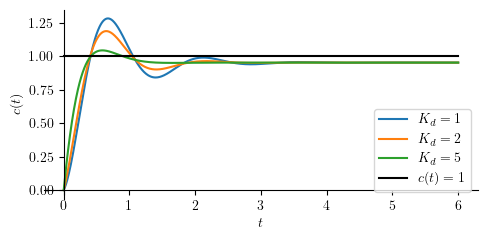

In [72]:
p = [plot(cpd.subs(([zeta, zeta_], [omega_n, omega_n_], [Kp, Kp_], [Kd, Kd_[j]])), 
          (t, 0, 6), size=(5, 2.5), ylabel='$c(t)$', show=False, legend=True, axis_center=[0,0]) 
     for j in range(len(Kd_))]
p1 = plot(1, (t, 0, 6), line_color='k', line_style=':', show=False) # unit-step
p1[0].label = "$c(t)=1$"
for j in range(len(p)):
    p[j][0].label = "$K_d=" + str(Kd_[j]) + "$"
    if j > 0:
        p[0].append(p[j][0])

p[0].append(p1[0])
p[0].show()


## Second-order system with PI-control 

Let us write down the closed-loop transfer function of a PI-controlled second-order system:

In [73]:
Qpi = simplify(Q.subs(Kd, 0))
mprintb("Q_{PI} =", latex(Qpi))

<IPython.core.display.Math object>

At this point we can no longer afford performing Inverse Laplace operation with SymPy since it is now involving finding root of a third orde polynomials. In order to find the steady state ouput, we will use __final value theorem__.

In [74]:
Cpi = Qpi*1/s
csspi = limit(s * Cpi, s, 0) 
mprint("C(s) =", latex(Cpi))
mprintb("c_{ss} = c(\\infty) =", latex(csspi))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

__At steady state, the output is 1 which means PI controlled system does not have steady state error.__

Next, we wll introduce $-a_1$, $-a_2$, and $-a_3$ as the roots of: $\left(K_i+2 \omega_n s^2 \zeta+s^3+s\left(K_p+\omega_n^2\right)\right)$

$$C(s)=\frac{K_i+K_p s}{s\left(K_i+2 \omega_n s^2 \zeta+s^3+s\left(K_p+\omega_n^2\right)\right)} = \frac{K_i+K_p s}{s(s+a_1)(s+a_3)(s+a_2)} $$

In [75]:
a1, a2, a3 = symbols('a1 a2 a3', complex=True)
Cpi_fac = (Kp*s + Ki) / (s*(s + a1)*(s + a2)*(s + a3))

mprint("C(s) = ", latex(Cpi_fac))

Cpi_pf = apart(Cpi_fac, s)

print("\nPartial fraction form")
mprint("C(s) = ", latex(Cpi_pf))

cpi = logcombine(inverse_laplace_transform(Cpi_pf, s, t))

print("\nInverse Laplace")
mprintb("c(t) = ", latex(cpi))

<IPython.core.display.Math object>


Partial fraction form


<IPython.core.display.Math object>


Inverse Laplace


<IPython.core.display.Math object>

We can now compute the intial output $c(0)$.

In [76]:
c0pi = simplify(cpi.subs(t, 0))
cpi_d = simplify(diff(cpi, t))
c0pi_d = limit(cpi_d, t, 0)

mprintb("c(0) = ", latex(c0pi))
mprint("c'(t) = ", latex(cpi_d))
mprintb("c'(0) = ", latex(c0pi_d))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Our conclusions: 
- no derivative kick
- smooth start
- zero initial velocity

Next, we can write the steady state error as: $e_{ss} = 1 - c_{ss}$

In this case, we will need to first find $a_1$, $a_2$, and $a_3$ (perhaps numerically). Then, we plug them into the later equation to find $c(t)$. Let us take some arbitrary numerical values so we can plot the controlled system's reponses.

In [77]:
tau_ = 1
Kp_ = 5
Ki_ = [0.5, 1, 2]
Kd_ = 0
omega_n_ = 1
zeta_ = 1

We must first calculate the denominator roots or $-a_1$, $-a_2$, and $-a_3$ by finding 3rd-order polynomial roots for each $K_i$.

In [78]:
ROOTS = []
for j in range(len(Ki_)):
    eq = Qpi.subs(([zeta, zeta_], [omega_n, omega_n_], [tau, tau_], [Kp, Kp_],[Ki, Ki_[j]]))
    root = solve(denom(eq),s)
    ROOTS.append([-root[k].evalf() for k in range(len(root))])
    mprint("K_i=", latex(Ki_[j]), "\\rightarrow", latex(ROOTS[j]))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

With $a_1$, $a_2$, and $a_3$ found, we now have the complete $c(t)$ responses for all $K_i$. This, we can plot the responses.

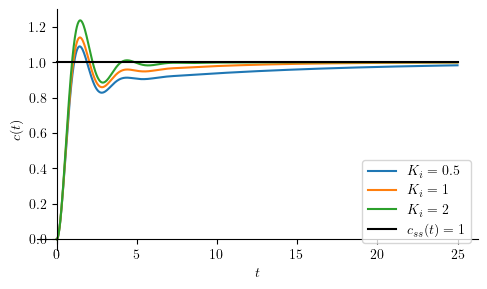

In [79]:
p = [plot(cpi.subs(([zeta, zeta_], [omega_n, omega_n_], [tau, tau_], [Kp, Kp_], [Ki, Ki_[j]],
                    [a1, ROOTS[j][0]], [a2, ROOTS[j][1]], [a3, ROOTS[j][2]])), (t, 0, 25), size=(5, 3), ylabel='$c(t)$', show=False, legend=True) for j in range(len(Ki_))]

for j in range(len(p)):
    p[j][0].label = "$K_i=" + str(Ki_[j]) + "$"
    if j > 0:
        p[0].append(p[j][0])

q = plot(csspi.subs(Kp, Kp_), (t, 0, 25), line_color='k', show=False)
q[0].label = "$ c_{ss} (t) = " + latex(csspi.subs(Kp, Kp_)) + " $"
p[0].append(q[0])
p[0].show()


## Second-order system with PID-control

This PID-control section is very similar to PI-control.

In [80]:
Qpid = Q
Cpid = Qpid * 1/s
mprint("Q_{PID}=", latex(Qpid))

csspid = limit(s * Cpid, s, 0) 
mprint("C(s) =", latex(Cpid))
mprintb("c_{ss} = c(\\infty) =", latex(csspid))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [81]:
a1, a2, a3 = symbols('a1 a2 a3', complex=True)
Cpid_fac = (Kd*s**2 + Kp*s + Ki) / (s*(s + a1)*(s + a2)*(s + a3))

mprint("C(s) = ", latex(Cpid_fac))

Cpid_pf = apart(Cpid_fac, s)

print("\nPartial fraction form")
mprint("C(s) = ", latex(Cpid_pf))

cpid = logcombine(inverse_laplace_transform(Cpid_pf, s, t))

print("\nInverse Laplace")
mprintb("c(t) = ", latex(cpid))

<IPython.core.display.Math object>


Partial fraction form


<IPython.core.display.Math object>


Inverse Laplace


<IPython.core.display.Math object>

In [82]:
c0pid = simplify(cpid.subs(t, 0))
cpid_d = simplify(diff(cpid, t))
c0pid_d = simplify(limit(cpid_d, t, 0))

mprintb("c(0) = ", latex(c0pid))
mprint("c'(t) = ", latex(cpid_d))
mprintb("c'(0) = ", latex(c0pid_d))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Our conclusions: 
- derivative kick
- non-smooth start
- non-zero initial velocity

Next, we can write the steady state error as: $e_{ss} = 1 - c_{ss}$

In [83]:
mprintb("e_{ss}=", latex(simplify(1-csspid)))

<IPython.core.display.Math object>

## Summary

### Initial and steady-state output for unit-step input

In [84]:
from pandas import DataFrame, set_option
from IPython.display import Markdown, display

def makelatex(args):
    return ["${}$".format(latex(a)) for a in args]

descs = ["P", 
         "PD",
         "PI",
         "PID"]

css_label = [cssp, csspd, csspi, csspid]
c_label   = [cp, cpd, cpi, cpid]
init      = [c0p, c0pd, c0pid, c0pid]
initd     = [c0p_d, c0pd_d, c0pi_d, c0pid_d]

dic = {''         : makelatex(descs), 
       '$c_{ss}$' : makelatex(css_label),
       '$c(0)$'   : makelatex(init),
       "$c'(0)$"  : makelatex(initd)}


df = DataFrame(dic)


In [85]:
Markdown(df.to_markdown(index=False))

|                       | $c_{ss}$                               | $c(0)$   | $c'(0)$   |
|:----------------------|:---------------------------------------|:---------|:----------|
| $\mathtt{\text{P}}$   | $\frac{K_{p}}{K_{p} + \omega_{n}^{2}}$ | $0$      | $0$       |
| $\mathtt{\text{PD}}$  | $\frac{K_{p}}{K_{p} + \omega_{n}^{2}}$ | $0$      | $K_{d}$   |
| $\mathtt{\text{PI}}$  | $1$                                    | $0$      | $0$       |
| $\mathtt{\text{PID}}$ | $1$                                    | $0$      | $K_{d}$   |

## Interactive PID Response of a Second-Order Plant

This section demonstrates the step response of a second-order plant controlled using a PID controller. The goal is to observe how the controller gains $K_p$, $K_i$, and $K_d$ affect the closed-loop response.

The plant is modeled as a standard second-order system with these parameters:

- $\zeta$ is the damping ratio,
- $\omega_n$ is the natural frequency.

The notebook then plots the response $c(t)$ to a unit-step input. 

The notebook also calculates common time-domain response characteristics, including:

- rise time,
- peak time,
- maximum overshoot,
- settling time using the 5% band,
- settling time using the 2% band,
- closed-loop pole locations.

__Required Python Packages__

This notebook uses `ipywidgets` for interactive sliders. If `ipywidgets` is not installed, run:

```bash
pip install ipywidgets

In [86]:
# Interactive PID / PI / PD response of a second-order plant
# This version uses derived closed-form equations.
#
# Plant:
#     G(s) = 1 / (s^2 + 2*zeta*wn*s + wn^2)
#
# Controller:
#     Q(s) = Kp + Ki/s + Kd*s
#
# Cases:
#     Ki > 0 : PID / PI case, third-order closed-loop response
#     Ki = 0 : PD case, second-order closed-loop response
#
# PI is automatically included by setting Kd = 0 while Ki > 0.

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from scipy.optimize import brentq


def closed_loop_denominator_pid(Kp, Ki, Kd, zeta, wn):
    """
    PID/PI closed-loop denominator:

        s^3 + (Kd + 2*zeta*wn)*s^2 + (Kp + wn^2)*s + Ki
    """
    return [
        1.0,
        Kd + 2.0*zeta*wn,
        Kp + wn**2,
        Ki
    ]


def closed_loop_denominator_pd(Kp, Kd, zeta, wn):
    """
    PD closed-loop denominator:

        s^2 + (Kd + 2*zeta*wn)*s + (Kp + wn^2)
    """
    return [
        1.0,
        Kd + 2.0*zeta*wn,
        Kp + wn**2
    ]


def closed_loop_poles_and_a_pid(Kp, Ki, Kd, zeta, wn):
    """
    Compute PID/PI closed-loop poles p_i, then define a_i = -p_i.

    The derived PID equation uses:

        (s + a1)(s + a2)(s + a3)

    while the actual poles are:

        s = -a1, -a2, -a3
    """
    den = closed_loop_denominator_pid(Kp, Ki, Kd, zeta, wn)
    poles = np.roots(den)
    a = -poles
    return poles, a, den


def closed_loop_poles_and_a_pd(Kp, Kd, zeta, wn):
    """
    Compute PD closed-loop poles p_i, then define b_i = -p_i.

    The derived PD equation uses:

        (s + b1)(s + b2)

    while the actual poles are:

        s = -b1, -b2
    """
    den = closed_loop_denominator_pd(Kp, Kd, zeta, wn)
    poles = np.roots(den)
    b = -poles
    return poles, b, den


def closed_form_pid_response(t, Kp, Ki, Kd, a):
    """
    Derived PID/PI closed-form unit-step response:

    C(s) =
        (Kd*s^2 + Kp*s + Ki)
        --------------------------------
        s*(s+a1)*(s+a2)*(s+a3)

    c(t) =
        Ki/(a1*a2*a3)

        - ((Kd*a3^2 + Ki - Kp*a3)*exp(-a3*t))
          / (a3*(a1-a3)*(a2-a3))

        + ((Kd*a2^2 + Ki - Kp*a2)*exp(-a2*t))
          / (a2*(a1-a2)*(a2-a3))

        - ((Kd*a1^2 + Ki - Kp*a1)*exp(-a1*t))
          / (a1*(a1-a2)*(a1-a3))

    This assumes a1, a2, and a3 are distinct.
    """
    t = np.asarray(t, dtype=float)

    a1, a2, a3 = a

    c_inf = Ki / (a1 * a2 * a3)

    term_a3 = -((Kd*a3**2 + Ki - Kp*a3) * np.exp(-a3*t)) / (
        a3 * (a1 - a3) * (a2 - a3)
    )

    term_a2 = ((Kd*a2**2 + Ki - Kp*a2) * np.exp(-a2*t)) / (
        a2 * (a1 - a2) * (a2 - a3)
    )

    term_a1 = -((Kd*a1**2 + Ki - Kp*a1) * np.exp(-a1*t)) / (
        a1 * (a1 - a2) * (a1 - a3)
    )

    c = c_inf + term_a3 + term_a2 + term_a1

    return np.real_if_close(c, tol=1000)


def closed_form_pd_response(t, Kp, Kd, b):
    """
    Derived PD closed-form unit-step response.

    For Ki = 0:

        Q(s) = Kp + Kd*s

    Closed-loop transfer function:

        C(s)/R(s) =
            (Kd*s + Kp)
            --------------------------------------------
            s^2 + (Kd + 2*zeta*wn)*s + (Kp + wn^2)

    For a unit-step input:

        C(s) =
            (Kd*s + Kp)
            ----------------------
            s*(s+b1)*(s+b2)

    Therefore:

        c(t) =
            Kp/(b1*b2)
            + (Kp - Kd*b1)/(b1*(b1-b2))*exp(-b1*t)
            + (Kp - Kd*b2)/(b2*(b2-b1))*exp(-b2*t)

    This assumes b1 and b2 are distinct.
    """
    t = np.asarray(t, dtype=float)

    b1, b2 = b

    c_inf = Kp / (b1 * b2)

    term_b1 = ((Kp - Kd*b1) * np.exp(-b1*t)) / (
        b1 * (b1 - b2)
    )

    term_b2 = ((Kp - Kd*b2) * np.exp(-b2*t)) / (
        b2 * (b2 - b1)
    )

    c = c_inf + term_b1 + term_b2

    return np.real_if_close(c, tol=1000)


def first_crossing_time(func, t_grid, y_grid, level):
    """Find first time where y(t) crosses a specified level."""
    f_grid = y_grid - level

    for k in range(len(t_grid) - 1):
        if f_grid[k] == 0:
            return t_grid[k]

        if f_grid[k] * f_grid[k + 1] < 0:
            t_left = t_grid[k]
            t_right = t_grid[k + 1]

            try:
                return brentq(
                    lambda tau: func(tau) - level,
                    t_left,
                    t_right
                )
            except ValueError:
                return None

    return None


def settling_time(t, y, y_final, tol):
    """Settling time: first time after which response stays inside ±tol band."""
    lower = (1.0 - tol) * y_final
    upper = (1.0 + tol) * y_final

    inside = (y >= lower) & (y <= upper)

    for k in range(len(t)):
        if np.all(inside[k:]):
            return t[k]

    return None


def roots_are_distinct(values, tol=1e-7):
    """Check whether root constants are sufficiently distinct."""
    values = np.asarray(values)

    for i in range(len(values)):
        for j in range(i + 1, len(values)):
            if abs(values[i] - values[j]) <= tol:
                return False

    return True


def plot_pid_response(Kp=10.0, Ki=3.0, Kd=1.0,
                      zeta=1.0, wn=1.0,
                      t_final=20.0):

    # Basic validation
    if wn <= 0:
        print("Please use wn > 0.")
        return

    if zeta <= 0:
        print("Please use zeta > 0.")
        return

    if Ki < 0:
        print("Please use Ki >= 0.")
        return

    if t_final <= 0:
        print("Please use t final > 0.")
        return

    t = np.linspace(0, t_final, 2500)

    # ------------------------------------------------------------
    # Case 1: PID / PI
    # ------------------------------------------------------------
    if Ki > 0:
        controller_type = "PID" if Kd > 0 else "PI"

        poles, a, den = closed_loop_poles_and_a_pid(Kp, Ki, Kd, zeta, wn)
        stable = np.all(np.real(poles) < 0)

        if not roots_are_distinct(a):
            print("The closed-loop poles are repeated or too close.")
            print("The derived PID partial-fraction equation assumes distinct poles.")
            print("Try changing Kp, Ki, Kd, zeta, or wn slightly.")
            return

        c_complex = closed_form_pid_response(t, Kp, Ki, Kd, a)
        c = np.real(c_complex)

        c_inf_from_poles = Ki / np.prod(a)
        c_inf = float(np.real_if_close(c_inf_from_poles))

        def c_of_t(tau):
            y = closed_form_pid_response(
                np.array([tau]), Kp, Ki, Kd, a
            )
            return float(np.real(y[0]))

        pole_constants_name = "a_i = -p_i"

    # ------------------------------------------------------------
    # Case 2: PD
    # ------------------------------------------------------------
    else:
        controller_type = "PD"

        poles, b, den = closed_loop_poles_and_a_pd(Kp, Kd, zeta, wn)
        stable = np.all(np.real(poles) < 0)

        if not roots_are_distinct(b):
            print("The closed-loop poles are repeated or too close.")
            print("The derived PD partial-fraction equation assumes distinct poles.")
            print("Try changing Kp, Kd, zeta, or wn slightly.")
            return

        c_complex = closed_form_pd_response(t, Kp, Kd, b)
        c = np.real(c_complex)

        c_inf_from_poles = Kp / np.prod(b)
        c_inf = float(np.real_if_close(c_inf_from_poles))

        def c_of_t(tau):
            y = closed_form_pd_response(
                np.array([tau]), Kp, Kd, b
            )
            return float(np.real(y[0]))

        pole_constants_name = "b_i = -p_i"

    # Rise time:
    # We keep your definition: first time c(t) reaches the unit reference c=1.
    tr = first_crossing_time(c_of_t, t, c, 1.0)

    # First crossing of 95% and 98% of final value
    t95 = first_crossing_time(c_of_t, t, c, 0.95*c_inf)
    t98 = first_crossing_time(c_of_t, t, c, 0.98*c_inf)

    # Settling time using 5% and 2% bands
    Ts_5 = settling_time(t, c, c_inf, 0.05)
    Ts_2 = settling_time(t, c, c_inf, 0.02)

    # Peak information
    peak_index = np.argmax(c)
    t_peak = t[peak_index]
    c_peak = c[peak_index]
    Mp = c_peak - c_inf

    if abs(c_inf) > 1e-12:
        percent_overshoot = 100.0 * Mp / c_inf
    else:
        percent_overshoot = np.nan

    # Plot
    plt.figure(figsize=(9, 5))
    plt.plot(t, c, linewidth=2,
             label=rf"$c(t)$ from derived {controller_type} equation")

    plt.axhline(1.0, linestyle="--", linewidth=1, label="unit reference")

    # Settling bands around c_inf
    plt.axhline(1.05*c_inf, linestyle="--", linewidth=1,
                label=r"$\pm 5\%$ band around $c(\infty)$")
    plt.axhline(0.95*c_inf, linestyle="--", linewidth=1)

    plt.axhline(1.02*c_inf, linestyle="-.", linewidth=1,
                label=r"$\pm 2\%$ band around $c(\infty)$")
    plt.axhline(0.98*c_inf, linestyle="-.", linewidth=1)

    # Rise time marker
    if tr is not None:
        plt.axvline(tr, linestyle="--", linewidth=1,
                    label=rf"$t_r={tr:.3g}$")
        plt.plot(tr, 1.0, "o")

    # 95% and 98% first-crossing markers
    if t95 is not None:
        plt.plot(t95, 0.95*c_inf, "o", label=rf"$t_{{95}}={t95:.3g}$")

    if t98 is not None:
        plt.plot(t98, 0.98*c_inf, "o", label=rf"$t_{{98}}={t98:.3g}$")

    # Peak marker
    plt.plot(t_peak, c_peak, "s", label=rf"peak at $t_p={t_peak:.3g}$")

    # Settling time markers
    if Ts_5 is not None:
        plt.axvline(Ts_5, linestyle="--", linewidth=1,
                    label=rf"$T_{{s,5\%}}={Ts_5:.3g}$")

    if Ts_2 is not None:
        plt.axvline(Ts_2, linestyle="-.", linewidth=1,
                    label=rf"$T_{{s,2\%}}={Ts_2:.3g}$")

    plt.xlabel("Time, t")
    plt.ylabel("Response, c(t)")
    plt.title(f"{controller_type}-Controlled Second-Order Plant Using Derived Closed-Form Equation")
    plt.grid(True)
    plt.legend(loc="best")
    plt.show()

    # Print information
    print(f"Controller type: {controller_type}")
    print()

    if Ki > 0:
        print("Closed-loop characteristic polynomial:")
        print("s^3 + b2*s^2 + b1*s + b0")
        print(f"b2 = {den[1]:.6g}")
        print(f"b1 = {den[2]:.6g}")
        print(f"b0 = {den[3]:.6g}")
    else:
        print("Closed-loop characteristic polynomial:")
        print("s^2 + b1*s + b0")
        print(f"b1 = {den[1]:.6g}")
        print(f"b0 = {den[2]:.6g}")

    print()

    print("Closed-loop poles p_i:")
    for k, p in enumerate(poles, start=1):
        print(f"p{k} = {p:.6g}")
    print()

    print(f"Values used in the derived equation, {pole_constants_name}:")
    if Ki > 0:
        for k, ak in enumerate(a, start=1):
            print(f"a{k} = {ak:.6g}")
    else:
        for k, bk in enumerate(b, start=1):
            print(f"b{k} = {bk:.6g}")

    print()
    print(f"Stable?      = {stable}")
    print(f"zeta         = {zeta:.6g}")
    print(f"wn           = {wn:.6g}")
    print()

    if Ki > 0:
        print(f"Product a1*a2*a3 = {np.prod(a):.6g}")
        print(f"Ki               = {Ki:.6g}")
        print(f"c(infty) from Ki/(a1*a2*a3) = {c_inf:.6g}")
    else:
        print(f"Product b1*b2    = {np.prod(b):.6g}")
        print(f"Kp               = {Kp:.6g}")
        print(f"c(infty) from Kp/(b1*b2) = {c_inf:.6g}")
        print("Note: PD control does not generally give c(infty)=1.")

    print()

    print(f"c(0)         = {c[0]:.6g}")
    print(f"max c(t)    = {c_peak:.6g}")
    print(f"t_peak      = {t_peak:.6g}")
    print(f"Mp          = {Mp:.6g}")
    print(f"%OS         = {percent_overshoot:.6g} %")
    print()

    if tr is not None:
        print(f"rise time tr, c(t)=1        = {tr:.6g}")
    else:
        print("rise time tr, c(t)=1        = not found in plotted time range")

    if t95 is not None:
        print(f"t95 first crossing          = {t95:.6g}")
    else:
        print("t95 first crossing          = not found in plotted time range")

    if t98 is not None:
        print(f"t98 first crossing          = {t98:.6g}")
    else:
        print("t98 first crossing          = not found in plotted time range")

    if Ts_5 is not None:
        print(f"settling time 5%            = {Ts_5:.6g}")
    else:
        print("settling time 5%            = not settled in plotted time range")

    if Ts_2 is not None:
        print(f"settling time 2%            = {Ts_2:.6g}")
    else:
        print("settling time 2%            = not settled in plotted time range")


Kp_slider = widgets.FloatSlider(
    value=10.0, min=0.0, max=50.0, step=0.1, description="Kp"
)

Ki_slider = widgets.FloatSlider(
    value=3.0, min=0.0, max=50.0, step=0.1, description="Ki"
)

Kd_slider = widgets.FloatSlider(
    value=1.0, min=0.0, max=20.0, step=0.1, description="Kd"
)

zeta_box = widgets.FloatText(value=1.0, description="zeta")
wn_box = widgets.FloatText(value=1.0, description="wn")
tf_box = widgets.FloatText(value=20.0, description="t final")

ui = widgets.VBox([
    widgets.HBox([Kp_slider, Ki_slider, Kd_slider]),
    widgets.HBox([zeta_box, wn_box, tf_box]),
])

out = widgets.interactive_output(
    plot_pid_response,
    {
        "Kp": Kp_slider,
        "Ki": Ki_slider,
        "Kd": Kd_slider,
        "zeta": zeta_box,
        "wn": wn_box,
        "t_final": tf_box,
    },
)

display(ui, out)

Output()